In [29]:
! pip install -U pip

In [30]:
#! pip install -U kagglehub pandas matplotlib geopandas pip scikit-learn
! pip install kagglehub pandas matplotlib geopandas pip scikit-learn umap-learn statsmodels

# we can continue our analisys from 01-EDA 
For time series analisys we choose the same domain adding more years

In [31]:
%reload_ext autoreload
import pandas as pd
import numpy as np
import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import geopandas as gpd
import seaborn as sns
from scipy.stats import entropy
from sklearn.preprocessing import OneHotEncoder
import os
from statlib.domain_tools import load_datasets_timeseries

In [32]:
%reload_ext autoreload

# 2009-2018
filnames = [
    "2009.csv",
    "2010.csv",
    "2011.csv",
    "2012.csv",
    "2013.csv",
    "2014.csv",
    "2015.csv",
    "2016.csv",
    "2017.csv",
    "2018.csv",
]
df_full = load_datasets_timeseries(filnames,omogenize=True)


Loading 2009.csv...
Loading 2010.csv...
Loading 2011.csv...
Loading 2012.csv...
Loading 2013.csv...
Loading 2014.csv...
Loading 2015.csv...
Loading 2016.csv...
Loading 2017.csv...
Loading 2018.csv...


Our dataset time range is composed by many years, from 2009 to 2018, 
we can focus only in a less window of time because our metric 
have a startig time for the computation.
  
For example a MAE metric for a regression model that predict the delay of a flight,
but it need a sort of "warm-up" time to be computed, and so we keep the most amount of contiguous data.

In [33]:
df_full['2018.csv'].iloc[:, :14].head()

,FL_DATE,OP_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME
0,2018-01-01,UA,2429,EWR,DEN,1517,1512.0,-5.0,15.0,1527.0,1712.0,10.0,1745,1722.0
1,2018-01-01,UA,2427,LAS,SFO,1115,1107.0,-8.0,11.0,1118.0,1223.0,7.0,1254,1230.0
2,2018-01-01,UA,2426,SNA,DEN,1335,1330.0,-5.0,15.0,1345.0,1631.0,5.0,1649,1636.0
3,2018-01-01,UA,2425,RSW,ORD,1546,1552.0,6.0,19.0,1611.0,1748.0,6.0,1756,1754.0
4,2018-01-01,UA,2424,ORD,ALB,630,650.0,20.0,13.0,703.0,926.0,10.0,922,936.0


In [34]:
df_full['2018.csv'].iloc[:, 14:].head()

,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,Unnamed: 27
0,-23.0,False,NaN,False,268.0,250.0,225.0,1605.0,NaN,NaN,NaN,NaN,NaN,NaN
1,-24.0,False,NaN,False,99.0,83.0,65.0,414.0,NaN,NaN,NaN,NaN,NaN,NaN
2,-13.0,False,NaN,False,134.0,126.0,106.0,846.0,NaN,NaN,NaN,NaN,NaN,NaN
3,-2.0,False,NaN,False,190.0,182.0,157.0,1120.0,NaN,NaN,NaN,NaN,NaN,NaN
4,14.0,False,NaN,False,112.0,106.0,83.0,723.0,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
def total_delay_series(df):
    delay = (
        df["ARR_DELAY"].clip(lower=0)
        + df["DEP_DELAY"].clip(lower=0)
    )

    cancelled = (
        df["CANCELLATION_CODE"].notna()
        & (df["CANCELLATION_CODE"] != "")
    )

    delay[cancelled] = delay.max()
    return delay


df_reduced = {
    df_name: pd.DataFrame({
        "DATETIME": df["FL_DATE"],
        "TOTAL_DELAY": total_delay_series(df)
    })
    for df_name, df in df_full.items()
}

The TOTAL_DELAY column is now ready for analysis,
and it can be used to evaluate the distribution of delays. 
It will be created and classificated focusing on user experience,
so that we can evaluate the disservice time for users.
The total delay is a sum of positive part of arrival and departure delay, 
and if the flight is cancelled the value is set to the maximum of the destruction time, 
only for the avoiding inifite values.

In [36]:
df_reduced['2018.csv'].head()


,DATETIME,TOTAL_DELAY
0,2018-01-01,0.0
1,2018-01-01,0.0
2,2018-01-01,0.0
3,2018-01-01,6.0
4,2018-01-01,34.0


In [37]:
df_reduced['2017.csv'].head()

,DATETIME,TOTAL_DELAY
0,2017-01-01,58.0
1,2017-01-01,76.0
2,2017-01-01,93.0
3,2017-01-01,174.0
4,2017-01-01,42.0


In [38]:
ts = pd.concat(df_reduced.values(), ignore_index=True)

In [39]:
ts = (
    pd.concat(df_reduced.values(), ignore_index=True)
      .groupby("DATETIME", as_index=False)["TOTAL_DELAY"]
      .sum()
)

In [40]:
ts["DATETIME"] = pd.to_datetime(ts["DATETIME"], errors="coerce")

In [41]:
ts = ts.set_index("DATETIME")
ts.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3590 entries, 2009-01-01 to 2018-12-31
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   TOTAL_DELAY  3590 non-null   float64
dtypes: float64(1)
memory usage: 56.1 KB


A sum of minuts of total delay for each day, from 2009 to 2018 is computed. We can see that
the total delay is not stationary, and it has a strong seasonality, 
with some peaks, and a poor trend. 
We can also see that there are some outliers, with a very high total delay, probably due to some extreme events, like snowstorms or hurricanes.

In [42]:
ts.head()

,TOTAL_DELAY
DATETIME,
2009-01-01,1052288.0
2009-01-02,1586381.0
2009-01-03,1846775.0
2009-01-04,1822903.0
2009-01-05,2166766.0


Now we have finally our time series for evaluate a bad user experience

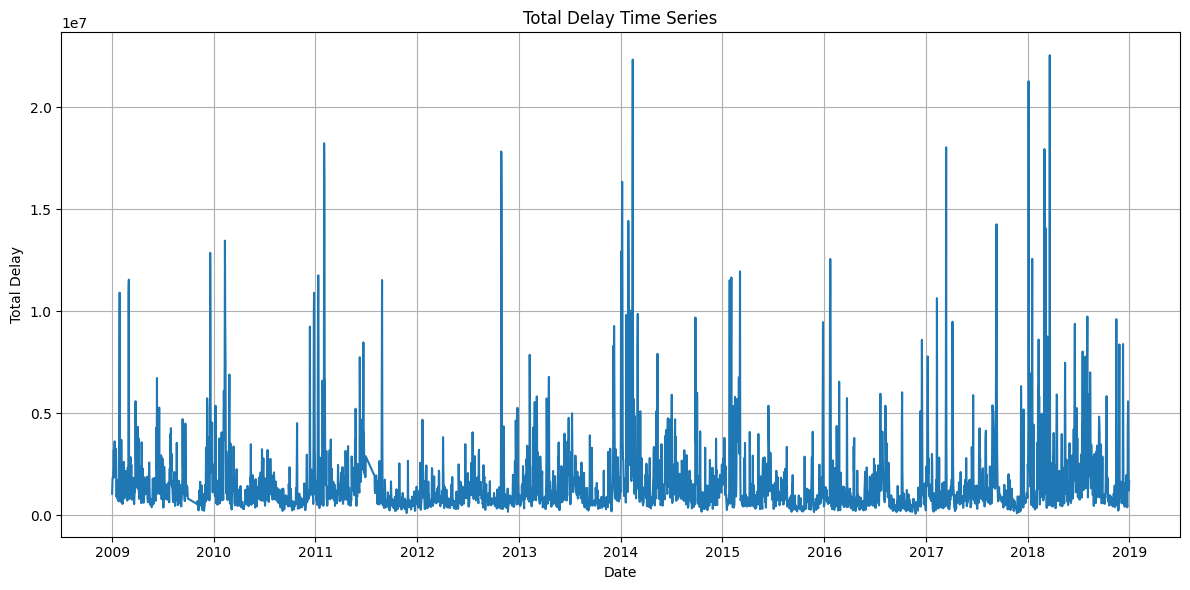

In [43]:
def ts_plot(*args, ):
    for ts in args:
        plt.figure(figsize=(12, 6))
        plt.plot(ts.index, ts.values)

        plt.xlabel("Date")
        plt.ylabel("Total Delay")
        plt.title("Total Delay Time Series")

        plt.grid(True)
        plt.tight_layout()
        plt.show()
ts_plot(ts)

As we can see we have a constant trend with additive seasonality

# Do we have missig values?


## **IMPUTATION METHODS:**

* Interpolation (Linear, Polynomial, Spline)
* Naive Seasonal Imputation

---

**Formula (Interpolation):**
$$
y_t \approx P(t)
$$

where:

* $P(t)$ is a polynomial, spline, or linear function fitted to valid neighboring data points.

Interpretation:

* Estimates missing values based on the structural trend of surrounding observations.
* Preferred over forward/backward fill or mean/median imputation when trend or seasonality is present, as it preserves the stochastic nature of the data.

Example:

* Filling a missing daily temperature reading using a cubic spline to preserve the smooth local trend without distorting the overall shape.

Python:

```python
# Linear or polynomial interpolation
df['col'].interpolate(method='cubic', limit_direction='forward', limit=5)
```

---

**Formula (Naive Seasonal Imputation):**
$$
y_t = y_{t-M}
$$

where:

* $M$ = length of the seasonal period (e.g., $M=7$ for daily data with weekly seasonality, $M=12$ for monthly data).

Interpretation:

* Replaces missing values with the observation from the most recent identical season.
* Highly effective and robust when strong seasonality is present and the underlying trend is mild or stable.

Example:

* Imputing a missing sales value for a specific Monday with the actual sales value recorded on the previous Monday.

Python:

```python
# Shift by seasonal period M (e.g., M=7) and fill NaNs
M = 7
df['col'] = df['col'].fillna(df['col'].shift(M))
```



In [ ]:
M = 365 # size of our  window


So no interpolation occour


## **SMOOTHING METHODS:**

* Centered Moving Average
* Trailing Moving Average 
* Exponential Smoothing

---

**Formula (Moving Average):**

Centered
$$
MA_t = \frac{1}{w} \sum_{i=-(w-1)/2}^{(w-1)/2} y_{t+i}
$$

Trailing
$$
MA_t = \frac{1}{w} \sum_{i=-(w-1)}^{0} y_{t+i}
$$

where:

* $w$ = window size
* trailing window is used for forecasting to avoid data leakage.

Interpretation:

* Averages values over multiple periods to reduce noise.
* Wider windows expose global trends; narrower windows reveal local trends.

Example:

* Smoothing out daily fluctuations to visualize the underlying monthly trend.

Python:

```python
df.rolling(window=w, center=False).mean()
```

---

**Formula (Exponential Smoothing):**
$$
EA_t = \alpha y_t + (1-\alpha)EA_{t-1}
$$

where:

* $\alpha$ = smoothing parameter ($0 < \alpha < 1$)

Interpretation:

* Weighted moving average where recent observations have higher influence.
* $\alpha \sim 1$ means fast adjustment; $\alpha \sim 0$ means slow adjustment.

Example:

* Imputing missing values in a series with a mild or absent trend.

Python:

```python
df[col].ewm(alpha=0.3, min_periods=0).mean()
```


##  Trend identification

These methods are based on inferring an equation hidden in the data and only take care of global patterns (trends and cycles).

* **Linear trend:** 
$$y_t = \beta_0 + \beta_1 t + \epsilon \qquad \epsilon \in \mathcal{N}(0,\sigma)$$



* **Exponential trend:** 
$$y_t = ce^{\beta_1 t + \epsilon} \qquad \log(y_t) = \beta_0 + \beta_1 t + \epsilon$$



* **Polynomial trend:** 
$$y_t = \beta_0 + \beta_1 t + \beta_2 t^2 + \epsilon$$





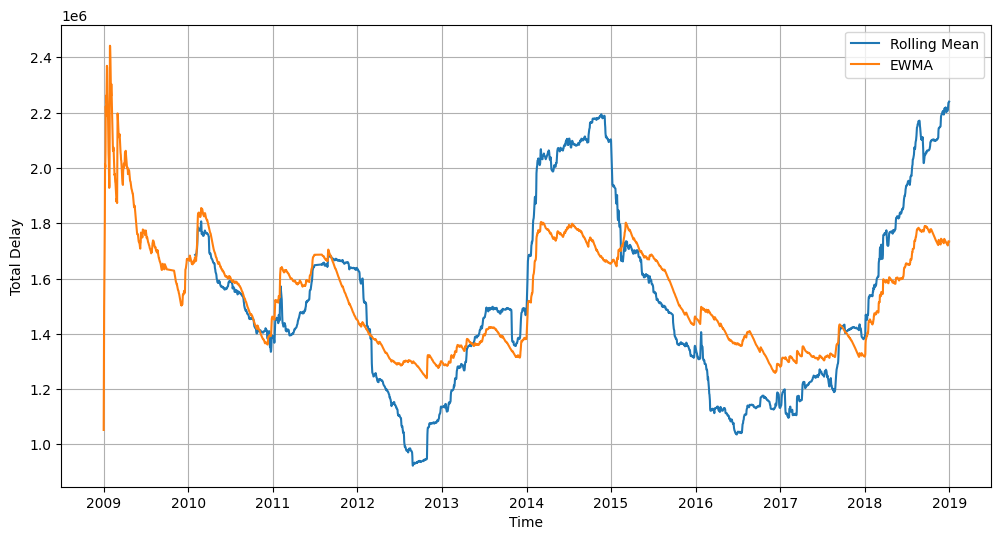

In [47]:
def ts_kplot(**kwargs, ):
    plt.figure(figsize=(12, 6))
    for title , ts in kwargs.items():
        plt.plot(ts.index, ts.values, label=title)
    plt.xlabel("Time")
    plt.ylabel("Total Delay")
    plt.grid(True)
    plt.legend()
    plt.show()

    



w = M

rolling = ts['TOTAL_DELAY'].rolling(window=w, center=False).mean()
smooth = ts.ewm(alpha=None, halflife=w, min_periods=0, 
                adjust=True, ignore_na=False).mean()


k_plot={
    "Rolling Mean": rolling,
    "EWMA": smooth
}


ts_kplot(**k_plot)

Comparing different avg copmutating methods can help us to understand the underlying 
trend of the data, and to identify any seasonality or cyclic patterns that may be present. 
By using different methods, we can also evaluate the robustness of our findings 
and ensure that our conclusions are not dependent on a specific averaging technique. 

Additionally, comparing different methods can provide insights into the variability and 
stability of the data, which can be crucial for making informed decisions based on the analysis.

Directly from our model pattern

![](img/ts-models.png)

# Time Series: Seasonality and Cycles


## **COMPONENTS & STRUCTURE:**

* Seasonality
* Additive Structure
* Multiplicative Structure

---

**Formula (Additive Seasonality):**
$$
y_t = Level + Trend + Seasonality + Noise
$$

where:

* $Seasonality$ represents short-term cyclical behavior repeating within the series.

Interpretation:

* The seasonal effect is constant in absolute magnitude over time, regardless of the overall level of the series.

Example:

* A store sells exactly 100 more umbrellas every rainy season, regardless of its total yearly sales growth.

---

**Formula (Multiplicative Seasonality):**
$$
y_t = Level \times Trend \times Seasonality \times Noise
$$
$$
\log(y_t) = \log(Level) + \log(Trend) + \log(Seasonality) + \log(Noise)
$$

Interpretation:

* The seasonal effect scales proportionally with the level of the series (variance increases as the trend grows).
* A log transformation is often applied to convert it into an additive form.

Example:

* Holiday sales increase by 20% every December; as the company grows, the absolute number of extra units sold in December also grows.

---

## **TESTS & METRICS:**

* Augmented Dickey-Fuller (ADF) test
* Ljung-Box test
* Formula (Autocorrelation function)

---

**Formula (ADF test regression):**
$$
\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^{p-1} \delta_i \Delta y_{t-i} + \varepsilon_t
$$

where:

* $H_0: \gamma = 0$ (series is non-stationary)
* $H_1: \gamma < 0$ (series is stationary)

Interpretation:

* Statistical test to determine the presence of a unit root.
* Rejecting $H_0$ indicates the time series is stationary.

Example:

* Checking if a stock price series needs differencing before modeling.

Python:

```python
from statsmodels.tsa.stattools import adfuller

adfuller(df['time_series'])
```


In [48]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts['TOTAL_DELAY'].dropna())
print("ADF statistic:", result[0])
print("p-value:", result[1])
print("critical values:", )
from pprint import pprint
pprint(result[4])
# stationary test ok

ADF statistic: -6.937715091351881
p-value: 1.0442127701955819e-09
critical values:
{'1%': np.float64(-3.432188208268577),
 '10%': np.float64(-2.567202356473299),
 '5%': np.float64(-2.8623522169902156)}


The time series is stationary for the test, but this test is non-resolutive. 
Out key value like p-value is less than 0.05 and the ADF statistic is less than the critical values at 1%, 5%, 
and 10% significance levels.



# Choosing AR lags

## AR(p) process

How to identify the maximum lag for an AR(p) process:

* Calculate and plot the sample partial autocorrelation function
* Look for where the PACF "cuts off", i.e., where it becomes statistically insignificant.



In [49]:
from statsmodels.tsa.ar_model import ar_select_order

# too heavy for big periods
selector = ar_select_order(ts['TOTAL_DELAY'].dropna(), maxlag=w//16, seasonal=True, period=w, exog=None )
lags_arp = selector.ar_lags
print(selector)
print("Selected lags:", lags_arp)

/media/simone/USB_projects/Usefull/ATTIVI/Esericizi/Big_data/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Selected lags: [1, 2]


/media/simone/USB_projects/Usefull/ATTIVI/Esericizi/Big_data/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)




*(Note inside the image chart: An arrow points to lag 3 indicating an **AR(3)** model because the PACF cuts off after lag 3).*

---

### Explanation of the Library and Code

The code snippet uses **`statsmodels`**, a prominent Python library used for estimating and testing statistical models, conducting statistical tests, and performing time series analysis.

Specifically, the function **`ar_select_order`** from the `statsmodels.tsa.ar_model` module is designed to **automatically select the optimal lag order ($p$) for an Autoregressive (AR) model**.

While the slide title mentions choosing lags "by hand" using a Partial Autocorrelation Function (PACF) plot, the Python code automates this selection process using information criteria.

Here is a breakdown of what the code does step-by-step:

1. **`from statsmodels.tsa.ar_model import ar_select_order`**
Imports the specific tool required to evaluate and select the best number of lags automatically.
2. **`selector = ar_select_order(...)`**
This function fits multiple AR models behind the scenes, varying the lag length up to a user-defined maximum (`maxlag`). By default, it evaluates these models using an information criterion, typically the **BIC (Bayesian Information Criterion)** or **AIC (Akaike Information Criterion)**. The model that minimizes this criterion value is selected as the optimal one because it achieves the best balance between goodness-of-fit and simplicity (avoiding overfitting).
* **`train['time_series'].dropna()`**: The input time series data, ensuring any missing data (`NaN`) values are removed.
* **`maxlag`**: The maximum number of lags the algorithm is allowed to check.
* **`seasonal` / `period` / `exog**`: Optional parameters to account for seasonality, the period length of the series, or exogenous variables (external regressors), respectively.


3. **`lags = selector.ar_lags`**
Extracts the results from the selection process. `selector.ar_lags` returns a list or an array containing the specific lag indices that were determined to be statistically optimal and chosen for inclusion in the final AR model.

**Formula (Autocorrelation function):**
$$
\gamma(h) = \frac{1}{n\sigma^2} \sum_{i=h+1}^{T} (y_t - \mu)(y_{t-h} - \mu)
$$

Interpretation:

* Measures the linear relationship between a time series and its lagged values.
* Slow decay indicates a trend; periodic spikes indicate seasonality.

Example:

* Identifying the seasonal lag $M$ by observing peaks at multiples of $M$ in the correlogram.

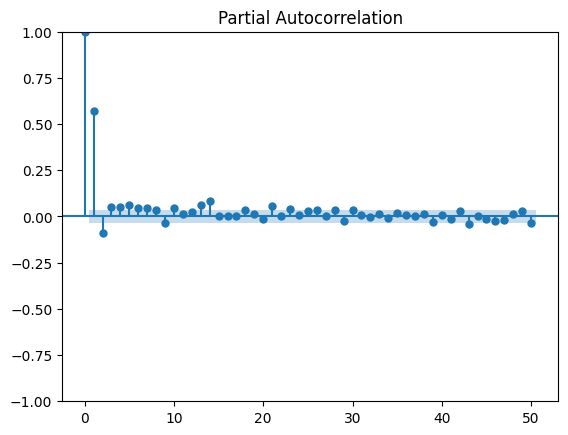

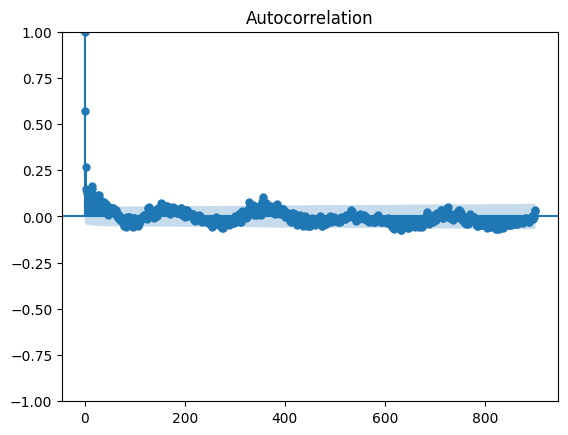

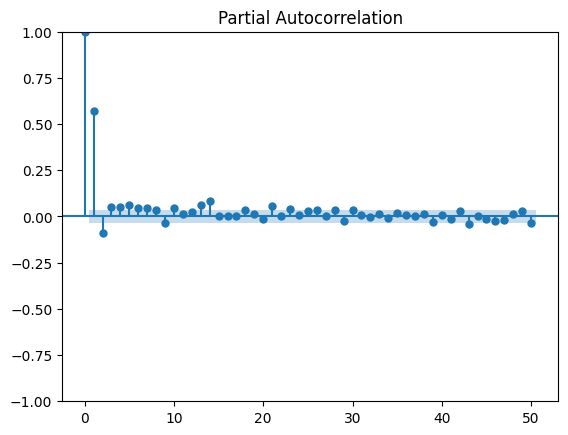

In [50]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(ts['TOTAL_DELAY'], lags=900)
plot_pacf(ts['TOTAL_DELAY'], lags=50) # AR lags autocorrelation 


As we can see from the ACF plot, there is a poor autocorrelation at lag 365, 
which suggests a yearly seasonality in the data. 

The PACF plot shows significant spikes at lags 1 and 2, 
indicating that these lags may be important for modeling the time series. 

The significant spike at lag 365 in the ACF plot confirms the presence of seasonality, 
while the PACF plot helps identify the order of the autoregressive model needed to capture this seasonality effectively.

In this case, we can consider using an ARIMA model for the identified seasonality and autocorrelation in the data.

---

**Formula (Ljung-Box test):**
$$
H_0: \gamma(h) = 0, \quad \forall 1 \leq h \leq H
$$

Interpretation:

* Tests whether a time series exhibits significant autocorrelation at multiple lags simultaneously.
* Commonly used to check if model residuals are white noise.

Example:

* Validating that an ARIMA model has successfully captured all autocorrelation in the data.


In [51]:
from statsmodels.stats.diagnostic import acorr_ljungbox

acorr_ljungbox(ts['TOTAL_DELAY'], return_df=True, lags=lags_arp)

,lb_stat,lb_pvalue
1,1173.009672,4.478225e-257
2,1429.366668,4.139727e-311


In the Ljung-Box test, the null hypothesis is that there is no autocorrelation in the time series.

A low p-value (typically less than 0.05) indicates that we can reject the null hypothesis, 
suggesting that there is significant autocorrelation in the data. 

For our numbers:
1. At lag 1: $p \approx 4.48 \times 10^{-257}$, reject $H_0$ strongly.
2. At lag 2: $p \approx 4.14 \times 10^{-311}$, reject $H_0$ strongly.


## How to make a time series stationary?

**Removing Trend:** A popular assumption is that the trend is linear or exponential over some time spans or the whole time period.

* **Lag-k Differencing:** $d_t^k = y_t - y_{t-k}$. For example, for a daily series, lag-7 differencing means subtracting from each value the value on the same day in the previous week.
* **Lag-1 differencing** is useful for removing a **linear trend**. One advantage of differencing over other methods (e.g., a regression with a trend) is that differencing does not assume that the trend is global, i.e., that the trend shape is fixed throughout the entire period.
* **Multiple Lag-1 differencing** for **quadratic, higher polynomial and exponential trends**.

**Regularise Noise:** if the noise is multiplicative, the variance of the time series will tend to increase/decrease in time. We need to make it nearly constant.

* **Log transformation:** regularises multiplicative noise stabilizing the variance of a time series.
* **Box-Cox transformation** can help regularising polynomial or multiplicative noise.

# DE-trending and de-seasonnalizin

* **Additive** $\quad y_t = \text{Trend} + \text{Seasonality} + \text{Noise}$
* **Multiplicative** $\quad y_t = \text{Trend} \times \text{Seasonality} \times \text{Noise}$



* `model` = `'additive'` or `'multiplicative'`
* `two_sided` = if `True` uses a centered rolling window, otherwise a trailing one. Mind not using `two_sided=True` for forecasting purposes.
* `period` = period of the series. To be specified if not using a pandas series with a date time index.
* `result` is an **object** containing trend, seasonality residuals, and a built-in plot function.

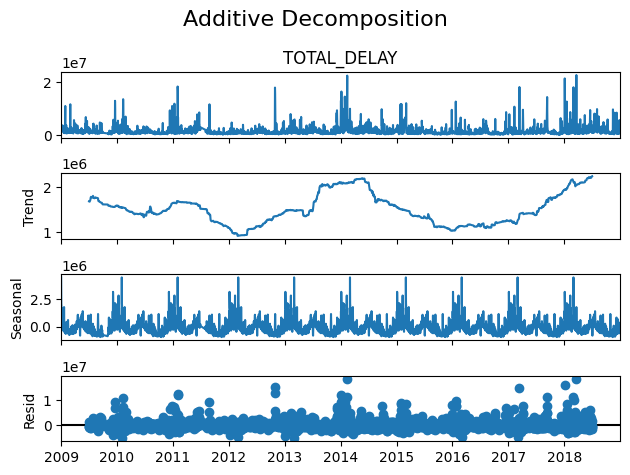

In [52]:

from statsmodels.tsa.seasonal import seasonal_decompose
w=365
additive = seasonal_decompose(ts['TOTAL_DELAY'], model='additive', period=w, two_sided=True)
additive.plot()
plt.suptitle("Additive Decomposition", fontsize=16)
plt.tight_layout()
plt.show()


Strong seasonality is evident in the data, with a clear yearly pattern. 

The trend component shows a general increase in total delays over time, 
while the residuals indicate some variability that is not explained by the trend or seasonality.

# Show in a log scale

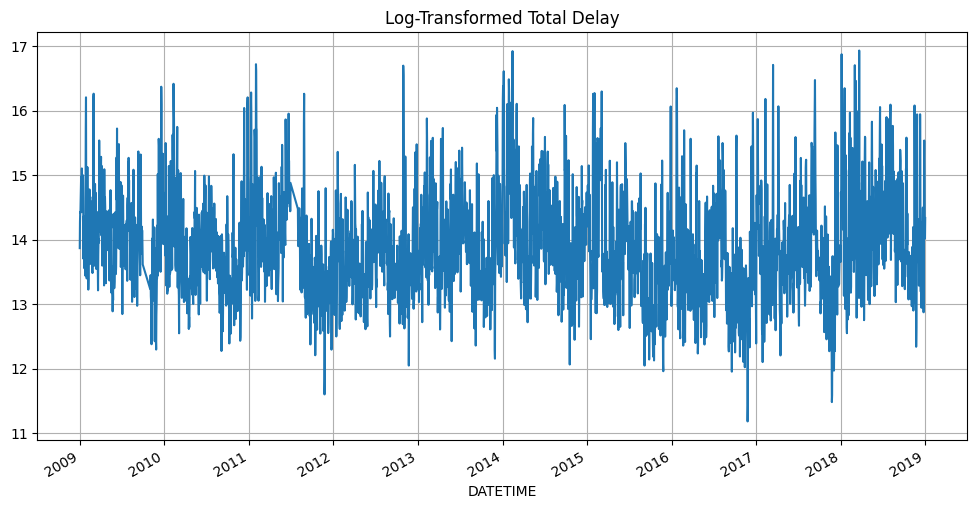

In [53]:
log=np.log(ts['TOTAL_DELAY'])
log.plot(figsize=(12, 6))
plt.title("Log-Transformed Total Delay")
plt.grid(True)
plt.show()

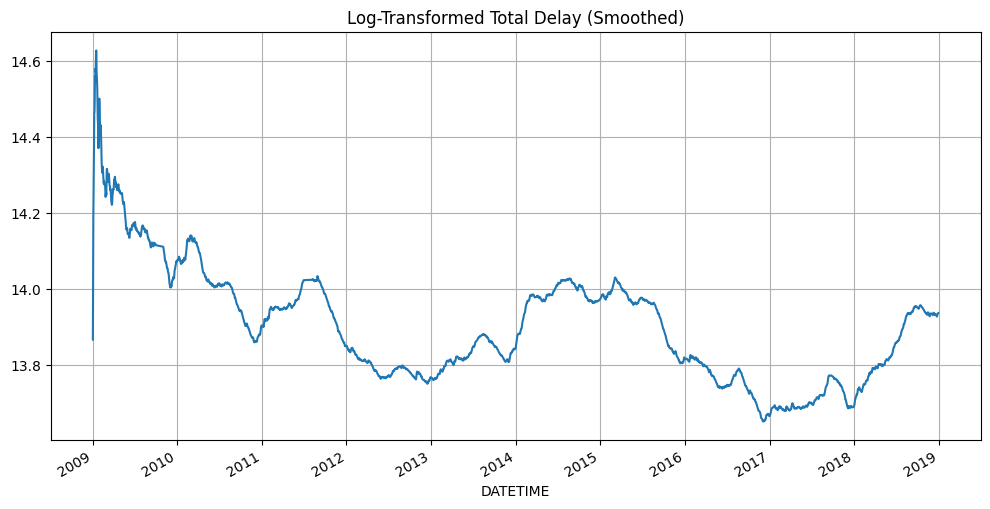

In [54]:
w=M
log=np.log(ts['TOTAL_DELAY'])
smooth = log.ewm(alpha=None, halflife=w, min_periods=0, 
                adjust=True, ignore_na=False).mean()
smooth.plot(figsize=(12, 6))
plt.title("Log-Transformed Total Delay (Smoothed)")
plt.grid(True)
plt.show()

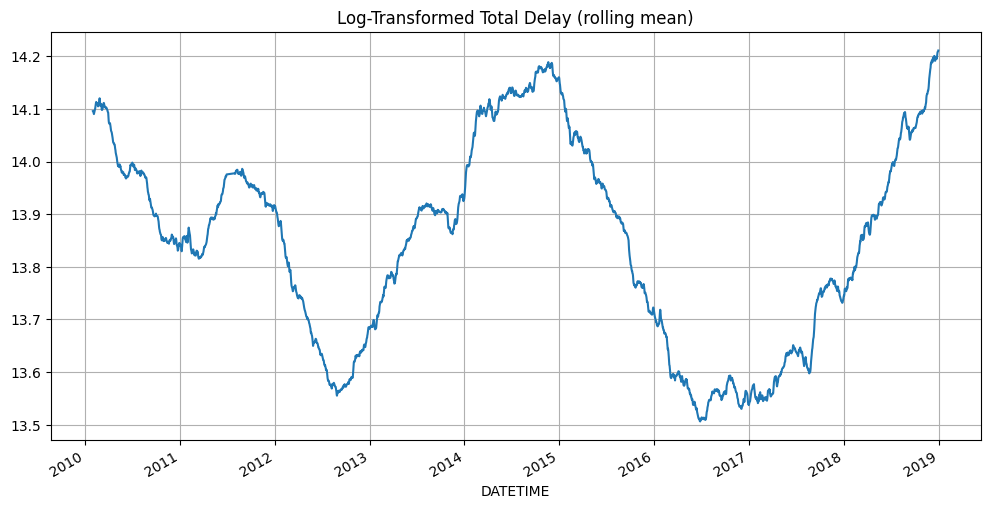

In [55]:
rolling = log.rolling(window=w, center=False).mean()
rolling.plot(figsize=(12, 6))
plt.title("Log-Transformed Total Delay (rolling mean)")
plt.grid(True)
plt.show()


# Linear autoregressive models


## **MODELS:**

* AR(p) process
* MA(q) process
* ARIMA(p,d,q) process

---

**Formula (AR(p) process):**
$$
y_t = \mu + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \dots + \phi_p y_{t-p} + \epsilon_t
$$

where:

* $\phi_i$ = autocorrelation with lag $i$
* $\epsilon_t \sim WN(0, \sigma^2)$

Interpretation:

* Models the series as a linear combination of its own past values.
* The order $p$ is identified using the Partial Autocorrelation Function (PACF).

Example:

* Forecasting temperature where today's value heavily depends on the last $p$ days.

Python:

```python
from statsmodels.tsa.ar_model import AutoReg

model = AutoReg(train['series'], seasonal=True, period = 180).fit()
forecast = model.forecast(steps=len(test))
```

---

**Formula (MA(q) process):**
$$
Y_t = \mu + \epsilon_t + \theta_1 \epsilon_{t-1} + \dots + \theta_q \epsilon_{t-q}
$$

where:

* $\theta_i$ = weight of the past shock $\epsilon_{t-i}$
* $\epsilon_t \sim WN(0, \sigma^2_\epsilon)$

Interpretation:

* Models the series as a weighted average of current and past white noise shocks.
* The order $q$ is identified where the Autocorrelation Function (ACF) cuts off.

Example:

* Modeling a series where unexpected shocks (like a sudden news event) only affect the next $q$ periods.

Python:

```python
import statsmodels.api as sm

# MA(2) is equivalent to ARIMA(0,0,2)
mod = sm.tsa.arima.ARIMA(endog, order=(0, 0, 2))
res = mod.fit()
```

---

**Formula (ARIMA(p,d,q) operator form):**
$$
(1 - \phi_1 B - \dots - \phi_p B^p)\Delta^d Y_t = (1 + \theta_1 B + \dots + \theta_q B^q)\epsilon_t
$$

where:

* $B$ = lag operator ($B^k Y_t = Y_{t-k}$)
* $\Delta$ = differencing operator ($\Delta Y_t = Y_t - Y_{t-1}$)
* $d$ = number of differences needed to achieve stationarity

Interpretation:

* Extends ARMA to non-stationary series by applying differencing $d$ times.
* Combines autoregressive (past values) and moving average (past errors) components.

Example:

* Forecasting non-stationary sales data that has a clear trend but no seasonality.

Python:

```python
import statsmodels.api as sm

mod = sm.tsa.arima.ARIMA(endog, order=(1, 1, 1))
res = mod.fit()
print(res.summary())
```

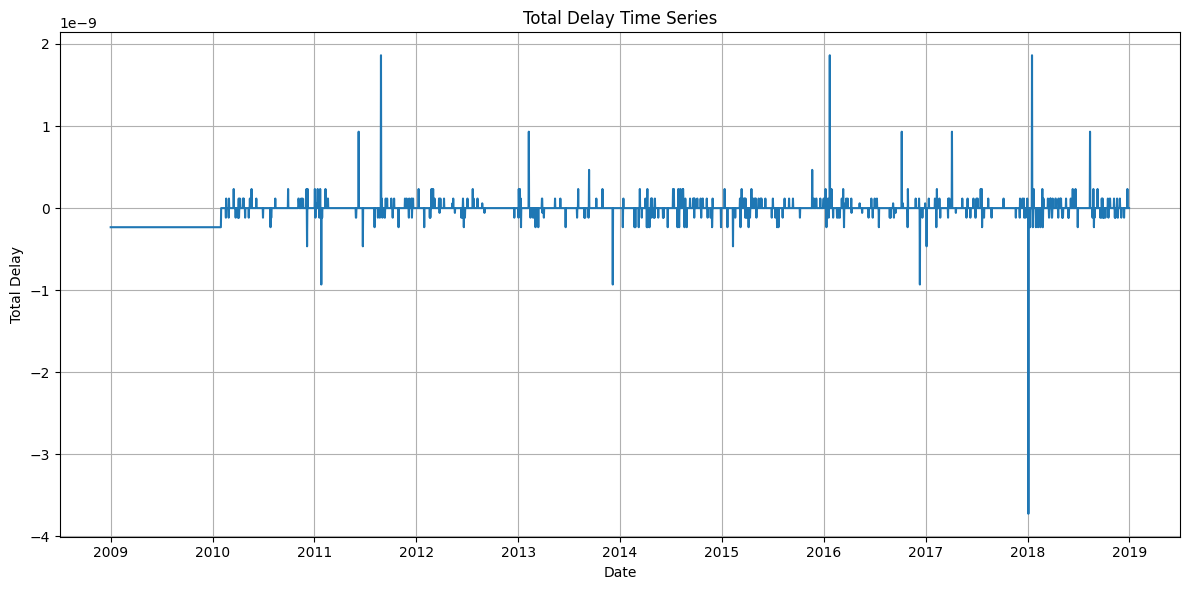

In [56]:
def symmetric_denoising(ts, model:str='additive', period=365):
    from statsmodels.tsa.seasonal import seasonal_decompose

    if hasattr(ts, 'squeeze'):
        ts = ts.squeeze()  # DataFrame (N,1) → Series (N,)

    noise = seasonal_decompose(ts, model=model, period=period, 
                               two_sided=False) # two sided has future information, so false is the right choice

    tot_noise = noise.trend + noise.seasonal + noise.resid  
    denoised_ts = ts - tot_noise  # solo trend rimosso, come prima

    return denoised_ts, tot_noise 

df = ts.copy()
log_df = log.copy()
det_deseas, noise_components = symmetric_denoising(df, period=w)

det_deseas = pd.DataFrame(det_deseas.values, index=df.index, columns=['TOTAL_DELAY'])

# fillna with rolling mean shifted by 45 days (half seasonality)
rolling = det_deseas.rolling(window=w, center=False).mean().shift(45)
det_deseas = det_deseas.fillna(rolling) 

ewm = det_deseas.ewm(alpha=None, halflife=w, min_periods=45,  adjust=True, ignore_na=False).mean()
det_deseas = det_deseas.fillna(ewm)  # fallback 1

det_deseas = det_deseas.ffill().bfill()  # fallback  2

log_rolling = log_df.rolling(window=w, center=False).mean()
det_deseas = det_deseas.fillna(log_rolling) # fallback 3


ts_plot(det_deseas)

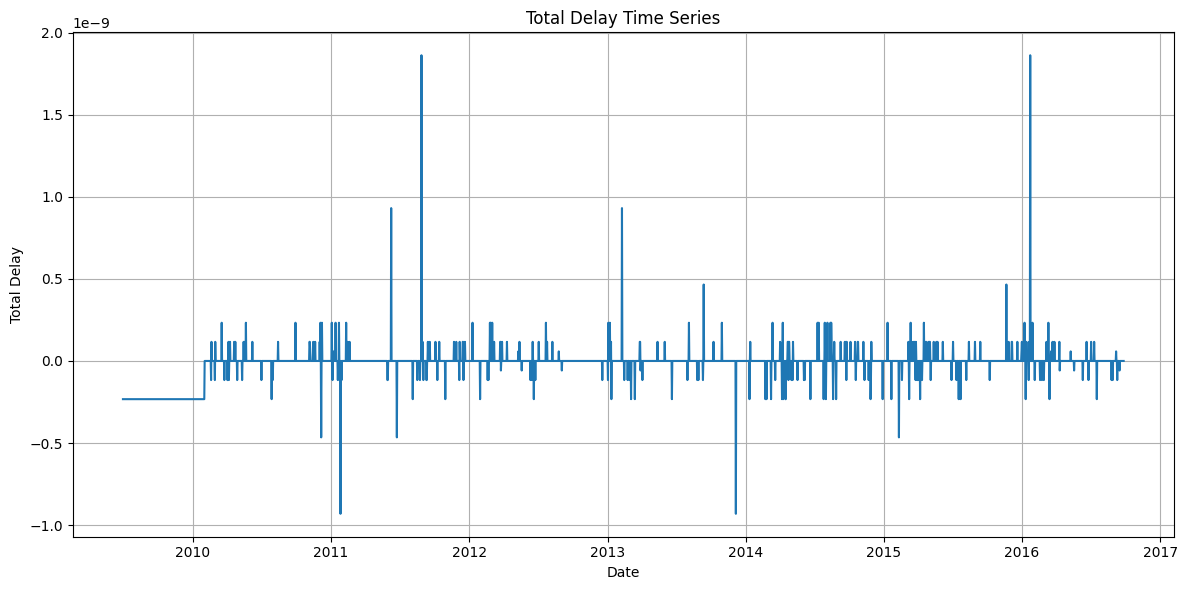

In [57]:
# from sklearn.model_selection import TimeSeriesSplit
# split train test
trash = 180
N = len(det_deseas) - trash*2  
test_size = 0.2
cut = int(N*(1-test_size))
train_denoised = det_deseas.iloc[trash:cut+trash].copy()
test_denoised = det_deseas.iloc[cut+trash:-trash].copy()


#from statsmodels.graphics.tsaplots import plot_pacf
ts_plot(train_denoised, )

In [58]:
from statsmodels.tsa.ar_model import AutoReg
model = AutoReg(train_denoised, lags=w , period = w).fit()
forecast_denoised = model.forecast(steps=len(test_denoised))
forecast_denoised.index = test_denoised.index

/media/simone/USB_projects/Usefull/ATTIVI/Esericizi/Big_data/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/media/simone/USB_projects/Usefull/ATTIVI/Esericizi/Big_data/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/media/simone/USB_projects/Usefull/ATTIVI/Esericizi/Big_data/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/media/simone/USB_projects/Usefull/ATTIVI/Esericizi/Big_data/venv/lib/python3.13/site-

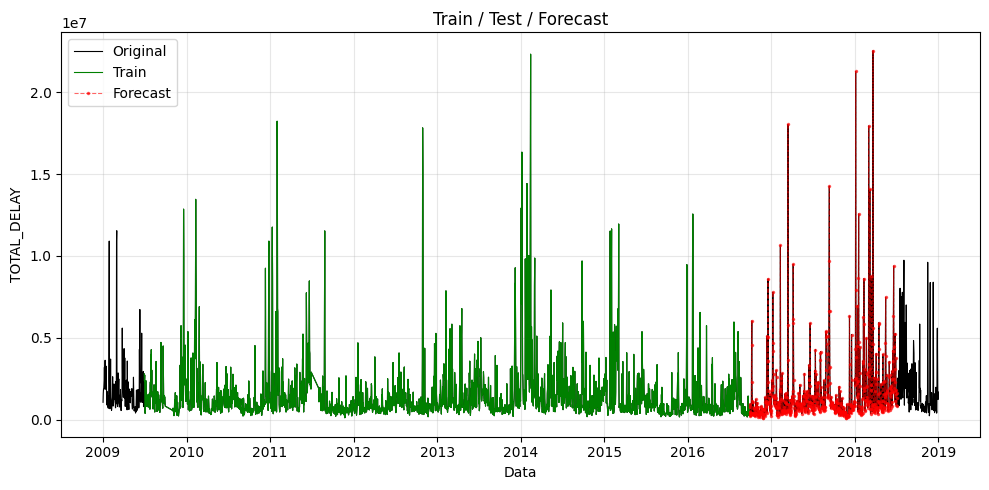

Original shape: (3590, 1)
Train Denoised shape: (2584, 1)
Test Denoised shape: (646, 1)
Noise Test shape: (646,)
Forecast Original shape: (646,)


In [59]:
noise_test = noise_components.loc[test_denoised.index]
forecast_original = forecast_denoised + noise_test

serie = ts['TOTAL_DELAY']

plt.figure(figsize=(10,5))
plt.plot(serie.index, serie, label='Original', color='black', linewidth=0.8)
plt.plot(train_denoised.index, serie.loc[train_denoised.index], label='Train', color='green', linewidth=0.8)
#plt.plot(test_denoised.index,  serie.loc[test_denoised.index],  label='Test',  color='blue', alpha=0.4, linewidth=0.8)
plt.plot(test_denoised.index,  forecast_original,               label='Forecast', color='red', alpha=0.6, linestyle='--', marker='.', markersize=3, linewidth=0.8)

#plt.axvline(train_denoised.index[-1], color='k', linestyle=':', alpha=0.7)
plt.legend()
plt.xlabel('Data')
plt.ylabel('TOTAL_DELAY')
plt.title('Train / Test / Forecast')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# check shape of all datasets to ensure alignment
print("Original shape:", ts.shape)
print("Train Denoised shape:", train_denoised.shape)  
print("Test Denoised shape:", test_denoised.shape)
print("Noise Test shape:", noise_test.shape)
print("Forecast Original shape:", forecast_original.shape)


In [60]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=serie.index, y=serie,
    name='Original', line=dict(color='black', width=0.8)
))
fig.add_trace(go.Scatter(
    x=train_denoised.index, y=serie.loc[train_denoised.index],
    name='Train', line=dict(color='green', width=0.8)
))
#fig.add_trace(go.Scatter(
#    x=test_denoised.index, y=serie.loc[test_denoised.index],
#    name='Test', line=dict(color='blue', width=0.8), opacity=0.4
#))
fig.add_trace(go.Scatter(
    x=test_denoised.index, y=forecast_original,
    name='Forecast', line=dict(color='red', width=0.8, dash='dash'),
    mode='lines+markers', marker=dict(size=3), opacity=0.6
))

# separatore train/test
fig.add_vline(
    x=train_denoised.index[-1],
    line=dict(color='black', dash='dot', width=1),
    opacity=0.7
)

fig.update_layout(
    title='Train / Test / Forecast',
    xaxis_title='Data',
    yaxis_title='TOTAL_DELAY',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0),
    hovermode='x unified',
    template='plotly_white',
    width=1000, height=500
)

fig.show()


**Formula (Seasonal ARIMA - SARIMA):**
$$
(1 - \phi_1 B - \dots)\Delta^d Y_t = (1 + \theta_1 B + \dots)(1 - \Phi_1 B^M - \dots)\Delta^D Y_t + \epsilon_t
$$

where:

* $(P, D, Q, M)$ is the `seasonal_order`, with $M$ being the periodicity.

Interpretation:

* Extends ARIMA by adding autoregressive and moving average terms that operate specifically at seasonal lags (e.g., lag $M, 2M$).
* Models both the non-seasonal dynamics and the cyclical seasonal dependencies simultaneously.

Example:

* Forecasting monthly airline passenger counts, modeling both the month-to-month random shocks and the strong yearly recurring pattern.


```python
class statsmodels.tsa.arima.model.ARIMA(endog, exog=None, order=(0, 0, 0), seasonal_order=(0, 0, 0, 0), trend=None, enforce_stationarity=True, enforce_invertibility=True, concentrate_scale=False, trend_offset=1, dates=None, freq=None, missing='none', validate_specification=True)
```

*   `endog` (`array_like`): The observed time-series process.
*   `exog` (`array_like`): Array of exogenous regressors.
*   `order` (`tuple`): the `(p,d,q)` order of the model. `d` is integer, while `p` and `q` may either be integers or lists of integers.
*   `seasonal_order` (`tuple`): The `(P,D,Q,s)` order of the seasonal component of the model. `s` is the periodicity.

```python
mod = sm.tsa.arima.ARIMA(endog, order=(1, 0, 0))
res = mod.fit()
print(res.summary())
```
```


### Basic residual analysis

- Define residuals of the fitted model $r_t = y_t - \hat{y}_t$
- We know that, in principle, they should be a pure stationary uncorrelated stochastic behavior. For this reason, we expect $r_t$ autocorrelation to be substantially vanishing for every non-vanishing lag.
- Moreover we should also check that the mean of the process is 0 as otherwise the model is biased (systematic under/over forecasting).

**Formula (Naive Seasonal Imputation):**
$$
y_t = y_{t-M}
$$

Interpretation:

* Replaces missing values with the observation from the most recent identical season.
* Superior to mean, median, or forward-fill imputation because it respects and preserves the underlying cyclical structure of the data.

Example:

* Filling a missing temperature reading for a specific Tuesday with the actual temperature recorded on the previous Tuesday.

Python:

```python
M = 7 # Weekly seasonality
# Fill NaNs with the value from M periods ago
df['series'] = df['series'].fillna(df['series'].shift(M))
```


# Conclusion

The code performs an exploratory data analysis (EDA) on flight delay data from 2009 to 2018.
The focus is to analyze the time series of total delays, which is computed by summing arrival and departure delays 
while accounting for cancellations. 
It processes the data to create a time series of total delays, 
applies smoothing techniques, tests for stationarity, 
and fits an AutoRegressive model to forecast future delays. 
The results are visualized using both Matplotlib and Plotly for better interactivity.